# 4. Adding forcing: waves, wind and water levels

**What this shows:** how rompy-xbeach turns wave, wind and tide datasets into XBeach
forcing files, with one example of each.

**Prerequisites:** [3. Bathymetry from your data](03_bathymetry.ipynb).

**You will learn:**

- the pattern shared by all forcing classes: *source → selection → files + params*
- the difference between grid, station and point data classes
- how to create a spectral wave boundary, a wind timeseries and a tide timeseries
- how to pick the right class for your data

**Data used:** `ww3-spectra-20230101-short.nc` (wave spectra at output sites of a
WAVEWATCH III model), `era5-20230101.nc` (ERA5 winds) and `swaus_tide_cons/` (gridded
tidal constituents).

## Setup

In [1]:
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from rompy.core.time import TimeRange
from rompy_xbeach.grid import RegularGrid

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "04_forcing"
shutil.rmtree(OUT_DIR, ignore_errors=True)
OUT_DIR.mkdir(parents=True)

grid = RegularGrid(
    ori={"x": 115.594239, "y": -32.641104, "crs": 4326},
    alfa=347.0,
    dx=10.0,
    dy=15.0,
    nx=230,
    ny=220,
    crs=28350,
)
period = TimeRange(start="2023-01-01T00", end="2023-01-01T12", interval="1h")

## 1. The data interface pattern

Every forcing object works the same way:

1. a **source** opens the dataset
2. the object **selects** data at the model location and period
3. `get(destdir, grid, period)` **writes** the XBeach file(s) and **returns** the
   parameters for `params.txt`

The class name says what kind of dataset it expects:

| Family | Dataset layout | Typical data |
|---|---|---|
| `...Grid` | fields on longitude/latitude dimensions | reanalysis winds, gridded wave parameters, tide models |
| `...Station` | many sites, each with its own coordinates | spectra at wave model output sites, station networks |
| `...Point` | a single timeseries without coordinates | a buoy or gauge record in a CSV file |

Grid and station data are selected at the grid centre (default) or the middle of the
offshore boundary (`location="offshore"`). Point data are used as they are.

## 2. Waves

Wave forcing drives the model at the offshore boundary. Here, 2D spectra from the
wave model site nearest the boundary are written as SWAN spectral files. The
directional grid (`thetamin`, `thetamax`, `dtheta`) is relative to the grid x-axis.

In [2]:
from rompy_xbeach.data.boundary import BoundaryStationSpectraSwan
from rompy_xbeach.source import SourceCRSWavespectra

wave = BoundaryStationSpectraSwan(
    source=SourceCRSWavespectra(
        uri=DATA_DIR / "ww3-spectra-20230101-short.nc", reader="read_ww3"
    ),
    location="offshore",
    sel_method="nearest",
    thetamin=-90.0,
    thetamax=90.0,
    dtheta=10.0,
)
wave_params = wave.get(destdir=OUT_DIR, grid=grid, time=period)
for key, value in wave_params.items():
    print(f"{key} = {value}")

wbctype = swan
bcfile = swan-20230101T000000.txt
thetamin = -90.0
thetamax = 90.0
dtheta = 10.0
dtbc = 1.0


The file holds the spectrum at the start of the run. `filelist=True` would write one
spectrum per source time step instead. The written file is a standard SWAN spectrum,
so wavespectra can read it back.

Hs = 2.84 m, Tp = 14.5 s


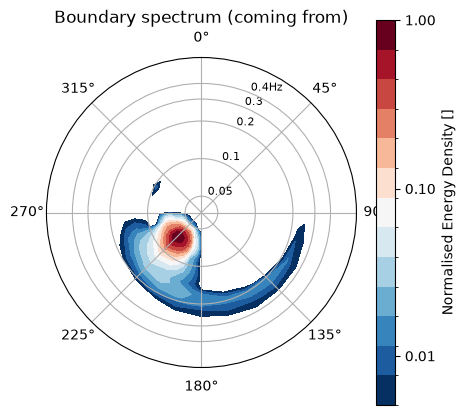

In [3]:
from wavespectra import read_swan

spectrum = read_swan(OUT_DIR / wave_params["bcfile"]).squeeze(drop=True)
print(f"Hs = {float(spectrum.spec.hs()):.2f} m, Tp = {float(spectrum.spec.tp()):.1f} s")
spectrum.spec.plot(figsize=(5, 5))
plt.title("Boundary spectrum (coming from)")
plt.show()

## 3. Wind

XBeach takes a single wind timeseries. `WindGrid` extracts it from gridded winds at
the grid centre. `WindVector` names the u and v components in the dataset
(`WindScalar` would name speed and direction variables instead).

In [4]:
from rompy_xbeach.data.wind import WindGrid, WindVector
from rompy_xbeach.source import SourceCRSFile

wind = WindGrid(
    source=SourceCRSFile(uri=DATA_DIR / "era5-20230101.nc", crs=4326),
    coords={"x": "longitude", "y": "latitude"},
    wind_vars=WindVector(u="u10", v="v10"),
)
wind_params = wind.get(destdir=OUT_DIR, grid=grid, time=period)
for key, value in wind_params.items():
    print(f"{key} = {value}")

windfile = wind-20230101T000000-20230101T120000.txt


Forcing timeseries are plain text files with the time in seconds since the start
of the run in the first column.

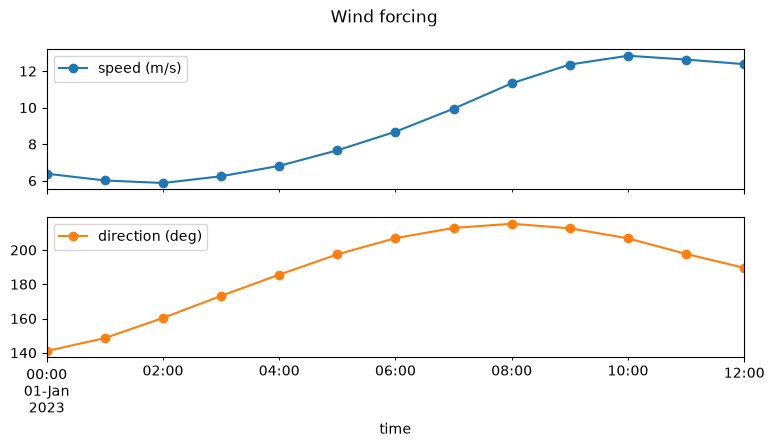

In [5]:
def read_timeseries(filename, columns):
    """Read an XBeach forcing timeseries into a dataframe indexed by time."""
    df = pd.read_csv(filename, sep=r"\s+", header=None, names=["tsec", *columns])
    df.index = period.start + pd.to_timedelta(df.pop("tsec"), unit="s")
    df.index.name = "time"
    return df


winds = read_timeseries(
    OUT_DIR / wind_params["windfile"], ["speed (m/s)", "direction (deg)"]
)
axes = winds.plot(subplots=True, marker="o", figsize=(9, 4), title="Wind forcing")

## 4. Water level

`TideConsGrid` predicts the tide from gridded tidal constituents, read here from an
OTIS tide model with oceantide. Other classes use measured or modelled water levels,
or add surge to the tide.

In [6]:
from rompy_xbeach.data.waterlevel import TideConsGrid
from rompy_xbeach.source import SourceCRSOceantide

cons_dir = DATA_DIR / "swaus_tide_cons"
tide = TideConsGrid(
    source=SourceCRSOceantide(
        reader="read_otis_binary",
        kwargs={
            "gfile": cons_dir / "grid_m2s2n2k2k1o1p1q1mmmf",
            "hfile": cons_dir / "h_m2s2n2k2k1o1p1q1mmmf",
            "ufile": cons_dir / "u_m2s2n2k2k1o1p1q1mmmf",
        },
        crs=4326,
    ),
    coords={"x": "lon", "y": "lat"},
)
tide_params = tide.get(destdir=OUT_DIR, grid=grid, time=period)
for key, value in tide_params.items():
    print(f"{key} = {value}")

zs0file = tide-20230101T000000-20230101T120000.txt
tideloc = 1
tidelen = 13


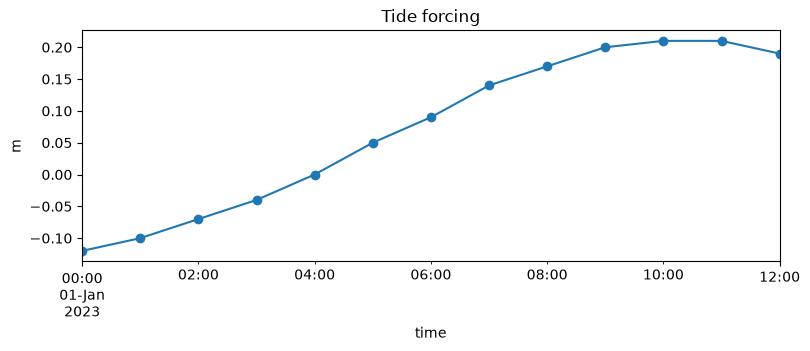

In [7]:
levels = read_timeseries(OUT_DIR / tide_params["zs0file"], ["water level (m)"])
ax = levels.plot(marker="o", figsize=(9, 3), legend=False, title="Tide forcing")
ax.set_ylabel("m")
plt.show()

## 5. Using forcing in a model

Forcing objects go in the `input` field of the `Config`. `ModelRun` calls their
`get()` methods for you when it writes the workspace.

```python
config = Config(
    grid=grid,
    bathy=bathy,
    input=DataInterface(wave=wave, wind=wind, tide=tide),
    physics=physics,
)
```

[Tutorial 6](06_complete_setup.ipynb) builds a full model with these three objects.

## 6. Which class do I need?

| My data | Wave class | Wind class | Water level class |
|---|---|---|---|
| Constant or simple conditions, no data | `BoundaryStat`, `BoundaryBichrom` | – | – (`zs0` constant) |
| 2D spectra at model output sites | `BoundaryStationSpectra{Jons,Jonstable,Swan}` | – | – |
| Wave parameters on a grid | `BoundaryGridParam{Jons,Jonstable}` | `WindGrid` | `WaterLevelGrid` |
| Parameters at stations | `BoundaryStationParam{Jons,Jonstable}` | `WindStation` | `WaterLevelStation` |
| A single timeseries (CSV, buoy) | `BoundaryPointParam{Jons,Jonstable}` | `WindPoint` | `WaterLevelPoint` |
| Tidal constituents | – | – | `TideConsGrid`, `TideConsPoint` |
| Existing XBeach boundary files | `BoundaryFile{Jons,Jonstable,Swan}` | – | – |

Each row is covered in detail in the examples:
[parametric waves](../examples/waves_parametric.ipynb),
[waves from spectra](../examples/waves_from_spectra.ipynb),
[waves from parameters](../examples/waves_from_parameters.ipynb),
[existing files and reuse](../examples/waves_from_files_and_reuse.ipynb),
[wind](../examples/wind.ipynb) and [water levels](../examples/water_levels.ipynb).

## Summary

- Forcing classes combine a source with a selection. `get()` writes files and returns
  parameters.
- Choose the class by data layout (grid, station or point) and by the XBeach file
  type you want.

**Next:** [5. Choosing model settings](05_model_settings.ipynb).